# Resampling algorithms and nodata handling

When `geokit.raster.warp` changes a raster's resolution (or reprojects it), it has to decide how
to combine source pixels into each output pixel. The `resampleAlg` argument selects that rule, and
**the choice can change the result substantially** -- especially when downsampling and when the
data contains nodata.

This example builds a small deterministic raster with a few telling features, downsamples it 2:1
with every available algorithm, and visualises the differences -- first without nodata, then with
a nodata region to show how each algorithm treats missing data.

Available algorithms: `near`, `bilinear`, `cubic`, `cubicspline`, `lanczos`, `average`, `rms`,
`mode`, `max`, `min`, `med`, `q1`, `q3`, `sum`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from geokit import raster, srs

ALGS = ["near", "bilinear", "cubic", "cubicspline", "lanczos", "average", "rms", "mode", "max", "min", "med", "q1", "q3", "sum"]

## A small, deterministic source raster

The 32x32 source combines features that each resampling rule handles differently:

- a **smooth diagonal ramp** (separates interpolation from nearest-neighbour),
- a **constant block**,
- a **sharp step edge** (exposes overshoot/ringing in cubic and lanczos),
- two **discrete class patches** (categorical data, relevant for `mode`/`near`),
- a single bright **spike** (shows each kernel's footprint).

This uses a similar construction to GeoKit's warp golden-regression tests, so the pictures here
line up with what the test suite checks. (Nodata is added further below, on a deliberately smaller
raster where it is easier to see.)

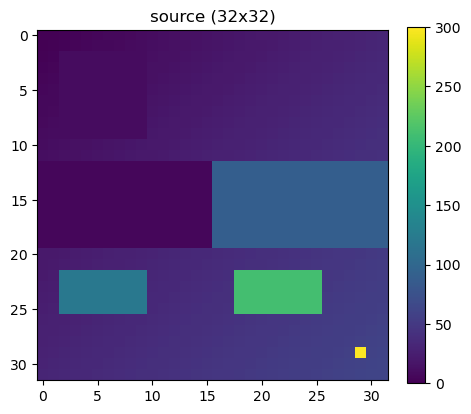

In [2]:
def build_source(pixel=100, noData=None):
    """A 32x32 in-memory raster with features that make resampling algorithms differ."""
    n = 32
    rows, cols = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")
    data = (rows + cols).astype(np.float32)  # smooth diagonal ramp (0..62)
    data[2:10, 2:10] = 10.0                  # constant block
    data[12:20, :16] = 5.0                   # step edge: low ...
    data[12:20, 16:] = 90.0                  # ... to high at column 16
    data[22:26, 2:10] = 120.0                # discrete class patch A
    data[22:26, 18:26] = 210.0               # discrete class patch B
    data[29, 29] = 300.0                     # single bright spike
    if noData is not None:
        data[5:11, 15:23] = noData           # nodata block
    return raster.createRaster(
        bounds=(0, 0, n * pixel, n * pixel),
        data=data,
        pixelWidth=pixel,
        pixelHeight=pixel,
        srs=srs.EPSG3035,
        noData=noData,
    )


source = build_source()
plt.figure(figsize=(5, 5))
h = plt.imshow(raster.extractMatrix(source), interpolation="nearest")
plt.title("source (32x32)")
plt.colorbar(h, fraction=0.046)
plt.show()

## Comparing the algorithms

We downsample 2:1 (100 m -> 200 m, so 32x32 -> 16x16). Each output pixel covers a 2x2 block of
source pixels, and the algorithm decides what value to assign:

- **`near`** picks the single nearest source pixel -- fast, keeps exact input values, but blocky.
- **`bilinear` / `cubic` / `cubicspline` / `lanczos`** are interpolating kernels of increasing
  width. They smooth the ramp; the higher-order kernels can *overshoot* near the step edge
  (values outside the input range -- visible ringing).
- **`average`** is the area-weighted mean -- the natural choice for downsampling continuous data;
  it preserves the mean. **`rms`** is the quadratic mean (>= average). **`sum`** adds the
  contributors (so values scale up by the area factor).
- **`mode`** returns the most common value -- the right choice for categorical/class rasters,
  since it never invents a value that was not in the input.
- **`min` / `max` / `med` / `q1` / `q3`** return order statistics of the contributing pixels.

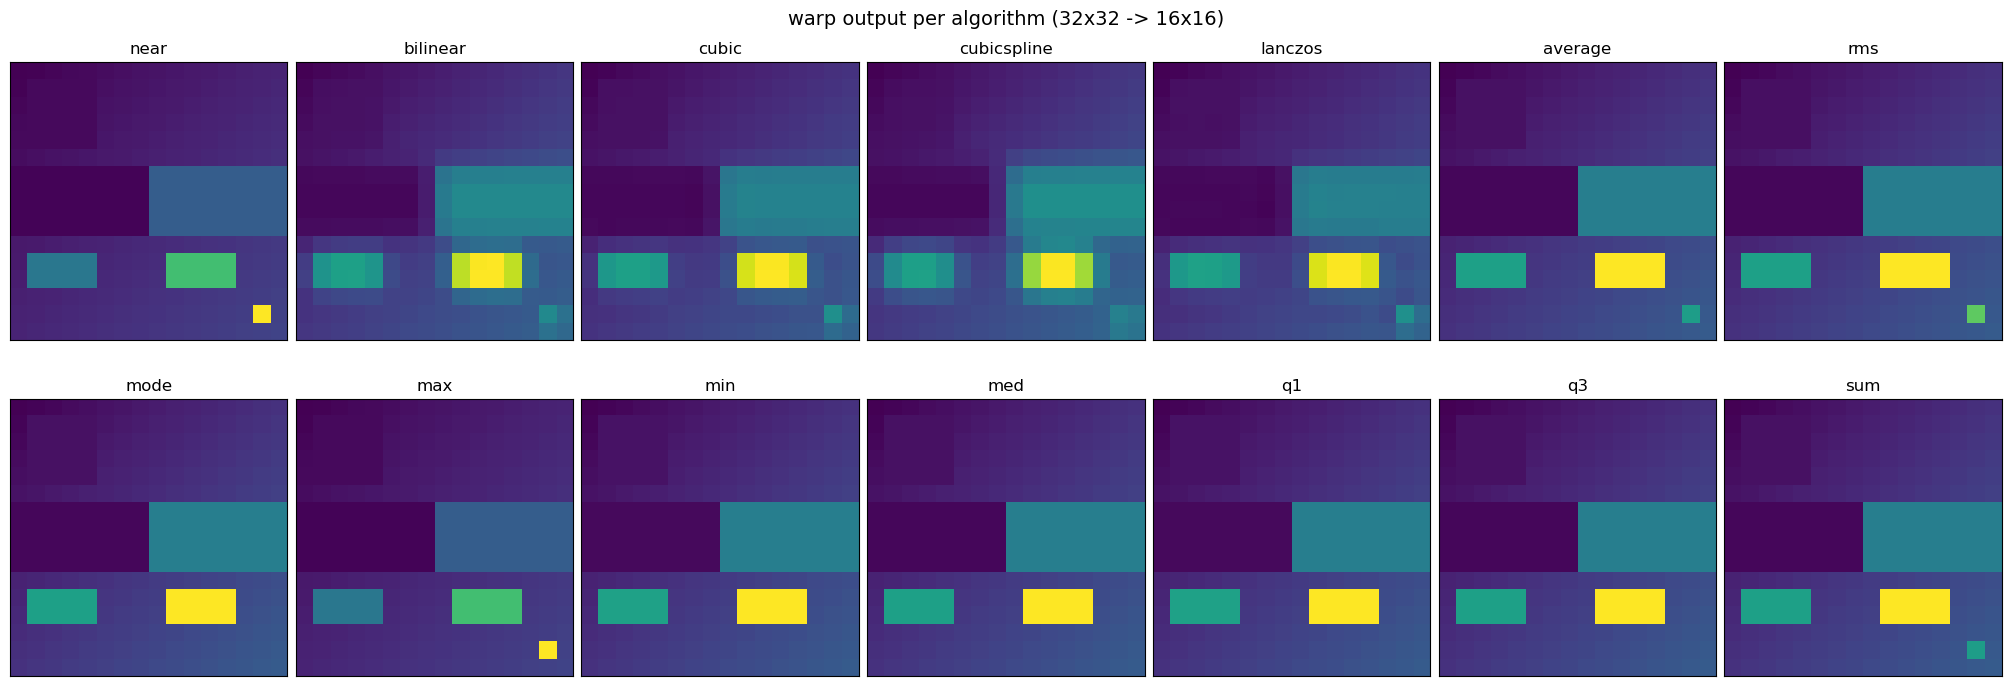

In [3]:
source = build_source()

# constrained_layout keeps the per-panel titles from colliding with the row above (tight_layout
# does not reserve room for the suptitle + titles in a dense 2x7 grid).
fig, axes = plt.subplots(2, 7, figsize=(20, 7), constrained_layout=True)
for ax, alg in zip(axes.ravel(), ALGS):
    out = raster.extractMatrix(raster.warp(source, resampleAlg=alg, pixelWidth=200, pixelHeight=200))
    h = ax.imshow(out, interpolation="nearest")
    ax.set_title(alg)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("warp output per algorithm (32x32 -> 16x16)", fontsize=14)
plt.show()

## Nodata handling

Real rasters usually carry a **nodata** value marking pixels with no valid measurement. How a
resampling algorithm treats nodata matters a great deal: a single nodata pixel can either
contaminate a whole output neighbourhood or be quietly ignored.

To make the effect easy to see, we switch to a deliberately **small 10x10 raster with a large
nodata block** and downsample it 2:1 to 5x5. On such a coarse output grid a single contaminated
pixel is unmistakable, so you can directly count how far nodata **bleeds** into neighbouring cells
(or does not). The nodata block is offset so its edges fall *inside* output pixels -- exactly the
case where the algorithms disagree. Nodata is drawn **blank (white)**, and each panel is annotated
with how many output pixels became nodata.

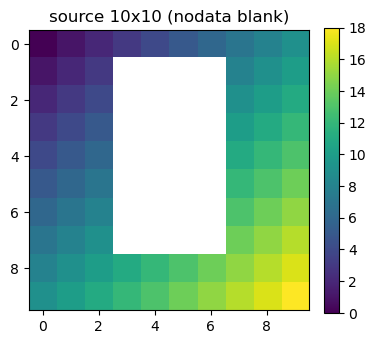

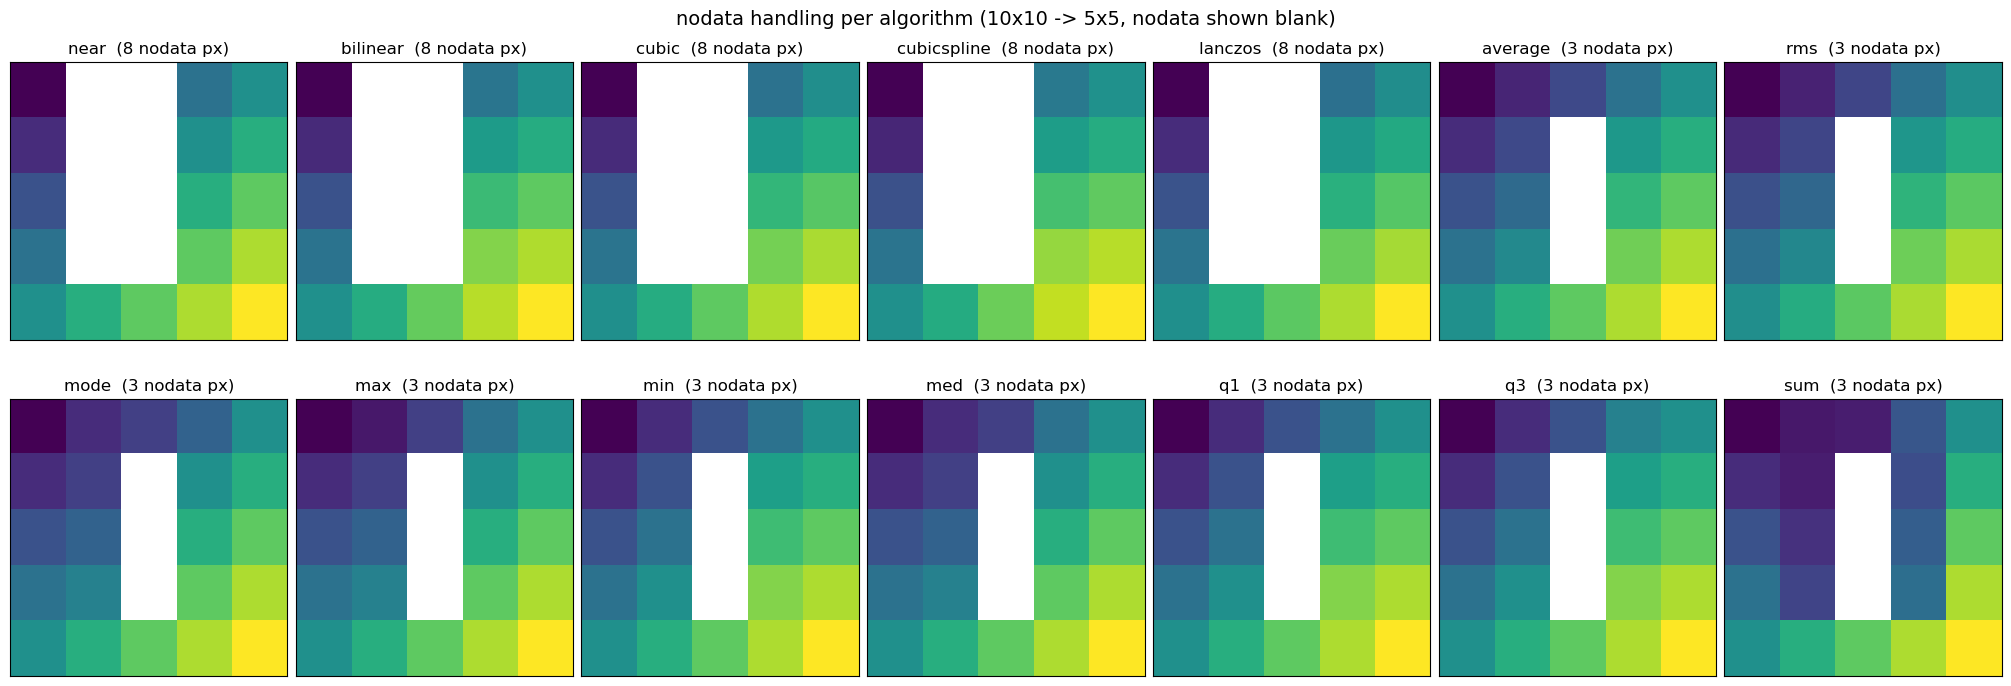

In [4]:
NODATA = -9999.0


def build_small_nodata(pixel=100, noData=NODATA):
    """A 10x10 raster with a large, offset nodata block -- chosen so nodata bleed is obvious at 2:1."""
    n = 10
    rows, cols = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")
    data = (rows + cols).astype(np.float32)  # gentle gradient so the valid cells stay readable
    data[1:8, 3:7] = noData                  # large nodata block straddling output-pixel edges
    return raster.createRaster(
        bounds=(0, 0, n * pixel, n * pixel),
        data=data,
        pixelWidth=pixel,
        pixelHeight=pixel,
        srs=srs.EPSG3035,
        noData=noData,
    )


def mask(mat):
    return np.where(mat == NODATA, np.nan, mat)


source_nd = build_small_nodata()

# The source: a 10x10 grid (downsampled 2:1 -> 5x5) with a large nodata block drawn blank.
plt.figure(figsize=(4, 4))
plt.imshow(mask(raster.extractMatrix(source_nd)), interpolation="nearest")
plt.title("source 10x10 (nodata blank)")
plt.colorbar(fraction=0.046)
plt.show()

fig, axes = plt.subplots(2, 7, figsize=(20, 7), constrained_layout=True)
for ax, alg in zip(axes.ravel(), ALGS):
    out = raster.extractMatrix(raster.warp(source_nd, resampleAlg=alg, pixelWidth=200, pixelHeight=200))
    ax.imshow(mask(out), interpolation="nearest")
    ax.set_title(f"{alg}  ({int((out == NODATA).sum())} nodata px)")  # single line -> no collision
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("nodata handling per algorithm (10x10 -> 5x5, nodata shown blank)", fontsize=14)
plt.show()

Two distinct behaviours emerge (and the per-panel counts make it concrete):

- **Kernel / point algorithms** (`near`, `bilinear`, `cubic`, `cubicspline`, `lanczos`) treat a
  nodata input as invalidating the output pixel it touches, so nodata **spreads** to every output
  pixel whose footprint overlaps the block.
- **Aggregating statistics** (`average`, `rms`, `mode`, `max`, `min`, `med`, `q1`, `q3`, `sum`)
  **ignore** nodata contributors and compute from the valid ones; an output pixel becomes nodata
  only when its *entire* footprint is nodata. This is why far fewer pixels are blank for these.

Neither is universally correct -- it depends on your data. For continuous fields where you want to
avoid bleeding gaps outward, the aggregating behaviour is usually preferable; for strict masking
you may want nodata to dominate.

## Choosing an algorithm

| Data / goal | Recommended | Avoid |
| --- | --- | --- |
| Continuous field (elevation, irradiance), downsampling | `average` (area-true, preserves mean) | `near` (blocky) |
| Continuous field, upsampling / smooth display | `bilinear`, `cubic` | `mode` |
| Categorical / class raster (land cover) | `mode` or `near` (never invent classes) | `bilinear`, `cubic`, `average` |
| Preserve totals (counts, area) | `sum` | mean-based algorithms |
| Keep extremes | `max` / `min` | `average` |

GeoKit runs the warp single-threaded with an explicit output grid, so these results are
deterministic and reproducible across runs. See the warp golden-regression tests
(`test/test_04_raster.py`) and the `test/test_case_inspector` notebook for the corresponding
regression checks and a debugging view.